# MULTIPLE HORIZON ENSEMBLE METHOD

## 0. Import & Global Variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.data_handler import *
from src.config_files import *
from src.direct_model import *
from src.mheme import *

In [13]:
WINDOW = 12
HORIZON = 4

DATA_PATH = '../data/solar.csv'

TCN_PATH_CONFIG_LOAD = '../src/config_files/tcn_config.json'
TCN_PATH_SAVE = '../models/tcn'

XGB_PATH_CONFIG_LOAD = '../src/config_files/xgb_config.json'
XGB_PATH_SAVE = '../models/xgb'

## 1. Load Data

In [14]:
data = pd.read_csv(DATA_PATH)
data = data[data['id'] == 0].sort_values('date').set_index('date')

X = data['power_mw']

In [15]:
X_slide, y_slide = sliding_window(X.to_numpy(), window=WINDOW, horizon=HORIZON)
train, val, test = train_validation_test_split(X_slide, y_slide)

## 2. Train naïve models

In [ ]:
### 2.1 Temporary Convolutional Networks
# model_tcn = TCN(TCN_PATH_CONFIG_LOAD)
# model_tcn.fit(train[0], train[1])

In [16]:
### 2.2 XGBoost
model_xgb = XGBoost(XGB_PATH_CONFIG_LOAD)
model_xgb.fit(train[0], train[1])

282.40586350375526

In [8]:
predictions_xgb = model_xgb.predict(test[0])

In [20]:
test[0][40], test[0][41]

(array([ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         2.  , 10.75, 15.25]),
 array([ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  2.  ,
        10.75, 15.25, 18.9 ]))

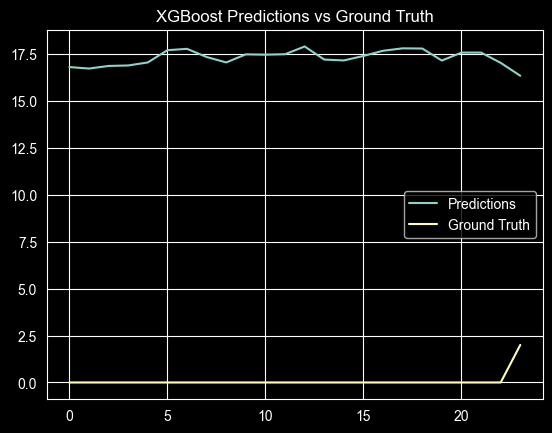

In [10]:
# Plot predictions vs ground truth for XGBoost
plt.plot(predictions_xgb[5], label='Predictions')
plt.plot(test[1][5], label='Ground Truth')
plt.legend()
plt.title('XGBoost Predictions vs Ground Truth')
plt.show()

## 3. Ensemble Method

In [ ]:
ensemble = UMHEMe(HORIZON, WINDOW, model_class=XGBoost, config_path=XGB_PATH_CONFIG_LOAD)
ensemble.fit(train[0], train[1])

In [ ]:
ensemble.predict(val[0])

In [ ]:
ensemble.compute_weights(val[0], val[1])

In [ ]:
preds = ensemble.predict(test[0])

In [ ]:
# preds vs test[1,
plt.plot(preds[0], label='Predictions')
plt.plot(test[1][0], label='Ground Truth')
plt.legend(),
plt.title('MHE Predictions vs Ground Truth')
plt.show()

In [ ]:
# preds vs test[1
plt.plot(preds[-1], label='Predictions')
plt.plot(test[1][-1], label='Ground Truth')
plt.legend()
plt.title('MHE Predictions vs Ground Truth')
plt.show()